# DATA PREPROCESSING

### Dataset: Sephora Products and Skincare Reviews

The dataset contains information about all beauty products (over 8,000) from the Sephora online store, including product and brand names, prices, ingredients, ratings, and all features.

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import ast




In [20]:
import kagglehub

path = kagglehub.dataset_download("nadyinky/sephora-products-and-skincare-reviews")

print("Path to dataset files:", path)

ReadTimeout: HTTPSConnectionPool(host='www.kaggle.com', port=443): Read timed out. (read timeout=5)

In [5]:
# List all files in the downloaded dataset directory
files = os.listdir(path)
print("Downloaded files:", files)

Downloaded files: ['product_info.csv', 'reviews_0-250.csv', 'reviews_1250-end.csv', 'reviews_250-500.csv', 'reviews_500-750.csv', 'reviews_750-1250.csv']


In [ ]:
csv_file = os.path.join(path, "product_info.csv")
df = pd.read_csv(csv_file)

# Check the first few rows of the dataframe
print(df.head())

  product_id               product_name  brand_id brand_name  loves_count  \
0    P473671    Fragrance Discovery Set      6342      19-69         6320   
1    P473668    La Habana Eau de Parfum      6342      19-69         3827   
2    P473662  Rainbow Bar Eau de Parfum      6342      19-69         3253   
3    P473660       Kasbah Eau de Parfum      6342      19-69         3018   
4    P473658  Purple Haze Eau de Parfum      6342      19-69         2691   

   rating  reviews            size                      variation_type  \
0  3.6364     11.0             NaN                                 NaN   
1  4.1538     13.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
2  4.2500     16.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
3  4.4762     21.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
4  3.2308     13.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   

  variation_value  ... online_only out_of_stock  sephora_exclusive  \
0             NaN  ...

In [7]:
print("Shape of the DataFrame:", df.shape)
print(df.info())



Shape of the DataFrame: (8494, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   object 
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   object 
 8   variation_type      7050 non-null   object 
 9   variation_value     6896 non-null   object 
 10  variation_desc      1250 non-null   object 
 11  ingredients         7549 non-null   object 
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     

We have 8494 records and 27 features, since we will not use all of them we can identify columns like brand_id and variation_desc, which are redundant or irrelevant for content-based filtering and drop them.

Import reviews and merge with product info

In [8]:
base_path = path

df_reviews_1 = pd.read_csv(os.path.join(base_path, "reviews_0-250.csv"),
                           index_col=0, dtype={'author_id': 'str'})
df_reviews_2 = pd.read_csv(os.path.join(base_path, "reviews_250-500.csv"),
                           index_col=0, dtype={'author_id': 'str'})
df_reviews_3 = pd.read_csv(os.path.join(base_path, "reviews_500-750.csv"),
                           index_col=0, dtype={'author_id': 'str'})
df_reviews_4 = pd.read_csv(os.path.join(base_path, "reviews_750-1250.csv"),
                           index_col=0, dtype={'author_id': 'str'})
df_reviews_5 = pd.read_csv(os.path.join(base_path, "reviews_1250-end.csv"),
                           index_col=0, dtype={'author_id': 'str'})



In [ ]:
df_reviews = pd.concat([df_reviews_1,df_reviews_2,df_reviews_3,df_reviews_4,df_reviews_5],axis=0)
print("df_reviews shape: ",df_reviews.shape)

df_reviews shape:  (1094411, 18)


In [10]:
# Lets check df_product_info which columns that similar with df_reviews
cols_to_use = df.columns.difference(df_reviews.columns)
cols_to_use = list(cols_to_use)
cols_to_use.append('product_id')
print(cols_to_use)

['brand_id', 'child_count', 'child_max_price', 'child_min_price', 'highlights', 'ingredients', 'limited_edition', 'loves_count', 'new', 'online_only', 'out_of_stock', 'primary_category', 'reviews', 'sale_price_usd', 'secondary_category', 'sephora_exclusive', 'size', 'tertiary_category', 'value_price_usd', 'variation_desc', 'variation_type', 'variation_value', 'product_id']


In [ ]:
df = pd.merge(df_reviews, df[cols_to_use], how='outer', on=['product_id', 'product_id'])
df.shape

(1100554, 40)

In [ ]:
missing = []
unique = []
types = []
variables = []
count = []

for item in df.columns:
    variables.append(item)
    missing.append(df[item].isnull().sum())
    unique.append(df[item].nunique())
    types.append(df[item].dtypes)
    count.append(len(df[item]))
    
output = pd.DataFrame({
    'variable': variables, 
    'dtype': types,
    'count': count,
    'unique': unique,
    'missing': missing, 
   
})
print("Df info : ")
output.sort_values("missing",ascending=False).reset_index(drop=True)

Df info : 


,variable,dtype,count,unique,missing
0,variation_desc,object,1100554,935,1091034
1,sale_price_usd,float64,1100554,88,1090576
2,value_price_usd,float64,1100554,174,1069365
3,child_max_price,float64,1100554,222,644796
4,child_min_price,float64,1100554,208,644796
5,helpfulness,float64,1100554,3767,567735
6,review_title,object,1100554,364105,316797
7,hair_color,object,1100554,7,232911
8,eye_color,object,1100554,6,215771
9,skin_tone,object,1100554,14,176682


Discard columns that are not useful

In [ ]:
df_old = df.copy()
columns_to_drop = [
    'variation_desc',             # Detailed variation description (not needed)
    'sale_price_usd',             # Sale price information
    'value_price_usd',            # Discounted price info
    'child_max_price',            # Variation-specific max price
    'child_min_price',            # Variation-specific min price
    'helpfulness',                # Review helpfulness score
    'review_title',               # Title of the review (optional)
    'tertiary_category',          # Extra categorization (if primary/secondary are sufficient)
    'highlights',                 # List of product highlights (not used in our current model)
    'variation_value',            # Specific variation detail
    'variation_type',             # Type of variation (redundant if not used)
    'size',                       # Product size (if not needed)
    'total_feedback_count',       # Feedback counts (can be considered noise)
    'total_neg_feedback_count',   # Negative feedback details
    'total_pos_feedback_count',   # Positive feedback details
    'submission_time',            # Timestamp of submission
    'limited_edition',            # Limited edition flag
    'sephora_exclusive',          # Exclusivity flag
    'child_count',                # Count of product variations
    'brand_id',                   # Numeric brand ID (redundant with brand_name)
    'online_only',
    'new'                 # Online-only flag (if not needed)
]

# Drop the unwanted columns from df
df_clean = df.drop(columns=columns_to_drop, axis=1)

# Verify the resulting DataFrame structure
print(df_clean.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100554 entries, 0 to 1100553
Data columns (total 18 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   author_id           1094411 non-null  object 
 1   rating              1094411 non-null  float64
 2   is_recommended      926423 non-null   float64
 3   review_text         1092967 non-null  object 
 4   skin_tone           923872 non-null   object 
 5   eye_color           884783 non-null   object 
 6   skin_type           982854 non-null   object 
 7   hair_color          867643 non-null   object 
 8   product_id          1100554 non-null  object 
 9   product_name        1094411 non-null  object 
 10  brand_name          1094411 non-null  object 
 11  price_usd           1094411 non-null  float64
 12  ingredients         1077711 non-null  object 
 13  loves_count         1100554 non-null  int64  
 14  out_of_stock        1100554 non-null  int64  
 15  primary_categor

## EDA

Basic data overview

In [ ]:
# Summary statistics for numerical columns
print(df_clean.describe())

# Summary for all columns (including object types)
print(df_clean.describe(include='all'))


             rating  is_recommended     price_usd   loves_count  out_of_stock  \
count  1.094411e+06   926423.000000  1.094411e+06  1.100554e+06  1.100554e+06   
mean   4.299158e+00        0.839962  4.900838e+01  1.064307e+05  3.182942e-02   
std    1.149444e+00        0.366642  4.004338e+01  1.674201e+05  1.755458e-01   
min    1.000000e+00        0.000000  3.000000e+00  0.000000e+00  0.000000e+00   
25%    4.000000e+00        1.000000  2.500000e+01  1.630000e+04  0.000000e+00   
50%    5.000000e+00        1.000000  3.900000e+01  4.814300e+04  0.000000e+00   
75%    5.000000e+00        1.000000  6.200000e+01  1.234390e+05  0.000000e+00   
max    5.000000e+00        1.000000  1.900000e+03  1.401068e+06  1.000000e+00   

            reviews  
count  1.100276e+06  
mean   2.151789e+03  
std    2.524573e+03  
min    1.000000e+00  
25%    5.390000e+02  
50%    1.337000e+03  
75%    2.891000e+03  
max    2.128100e+04  
         author_id        rating  is_recommended  \
count      1094411  

#### Handle missing data

In [ ]:
# Count missing values per column
missing_values = df_clean.isnull().sum()
print("Missing Values per Column:\n", missing_values)

# Optionally, view the percentage of missing values for each column
missing_percentage = (df_clean.isnull().mean() * 100).round(2)
print("Percentage of Missing Values:\n", missing_percentage)


Missing Values per Column:
 author_id               6143
rating                  6143
is_recommended        174131
review_text             7587
skin_tone             176682
eye_color             215771
skin_type             117700
hair_color            232911
product_id                 0
product_name            6143
brand_name              6143
price_usd               6143
ingredients            22843
loves_count                0
out_of_stock               0
primary_category           0
reviews                  278
secondary_category         8
dtype: int64
Percentage of Missing Values:
 author_id              0.56
rating                 0.56
is_recommended        15.82
review_text            0.69
skin_tone             16.05
eye_color             19.61
skin_type             10.69
hair_color            21.16
product_id             0.00
product_name           0.56
brand_name             0.56
price_usd              0.56
ingredients            2.08
loves_count            0.00
out_of_stock  

After analyzing the missing values, we found that critical text fields used for vectorization—specifically, the 'ingredients' (2.08% missing) and 'review_text' (0.69% missing) columns—needed to be complete for accurate text processing. Therefore, we dropped rows where these fields were missing. For other essential fields such as 'author_id', 'rating', 'product_name', 'brand_name', and 'price_usd', which had very low missing percentages (<1%), we also removed any incomplete rows to ensure data integrity. In contrast, the user attribute columns—'skin_tone' (16.05%), 'eye_color' (19.61%), 'skin_type' (10.69%), and 'hair_color' (21.16%)—had moderate missing rates; instead of dropping these, we imputed their missing values with a placeholder value ("Unknown") to preserve the overall dataset size.

In [ ]:

# Step 1: Drop rows with missing critical text fields and essential identifiers.
critical_columns = ['ingredients', 'review_text', 'author_id', 'rating', 'product_name', 'brand_name', 'price_usd','secondary_category']
df = df_clean.dropna(subset=critical_columns, how='any')

# Step 2: Impute missing values for user attribute columns with "Unknown".
user_attribute_columns = ['skin_tone', 'eye_color', 'skin_type', 'hair_color']
for col in user_attribute_columns:
    df[col] = df[col].fillna("Unknown")

# Optional: Verify the updated missing values summary.
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)

print("Updated Missing Values per Column:\n", missing_values)
print("\nPercentage of Missing Values:\n", missing_percentage)

C:\Users\tanja\AppData\Local\Temp\ipykernel_23576\866403099.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna("Unknown")


Updated Missing Values per Column:
 author_id                  0
rating                     0
is_recommended        160594
review_text                0
skin_tone                  0
eye_color                  0
skin_type                  0
hair_color                 0
product_id                 0
product_name               0
brand_name                 0
price_usd                  0
ingredients                0
loves_count                0
out_of_stock               0
primary_category           0
reviews                    0
secondary_category         0
dtype: int64

Percentage of Missing Values:
 author_id              0.0
rating                 0.0
is_recommended        15.0
review_text            0.0
skin_tone              0.0
eye_color              0.0
skin_type              0.0
hair_color             0.0
product_id             0.0
product_name           0.0
brand_name             0.0
price_usd              0.0
ingredients            0.0
loves_count            0.0
out_of_stock       

#### Product Labels

In [ ]:
# 1. Display unique value counts for both columns
print("Primary Category Counts:")
print(df['primary_category'].value_counts())
print("\nSecondary Category Counts:")
print(df['secondary_category'].value_counts())

Primary Category Counts:
primary_category
Skincare    1070962
Name: count, dtype: int64

Secondary Category Counts:
secondary_category
Moisturizers              289469
Treatments                219608
Cleansers                 199576
Mini Size                  83894
Eye Care                   74414
Masks                      67428
Lip Balms & Treatments     61519
Sunscreen                  40678
Value & Gift Sets          11830
Self Tanners               11420
Wellness                    8748
High Tech Tools             2363
Shop by Concern               15
Name: count, dtype: int64


Drop primary_category column because it only contains a single unique value.


In [33]:
df = df.drop(columns=['primary_category'])


In [34]:
df = df[df['secondary_category'].str.lower() != 'shop by concern']
print("After filtering, unique values in secondary_category:", df['secondary_category'].unique())

After filtering, unique values in secondary_category: ['Eye Care' 'Treatments' 'Moisturizers' 'Cleansers'
 'Lip Balms & Treatments' 'Masks' 'Sunscreen' 'Value & Gift Sets'
 'High Tech Tools' 'Wellness' 'Self Tanners' 'Mini Size']


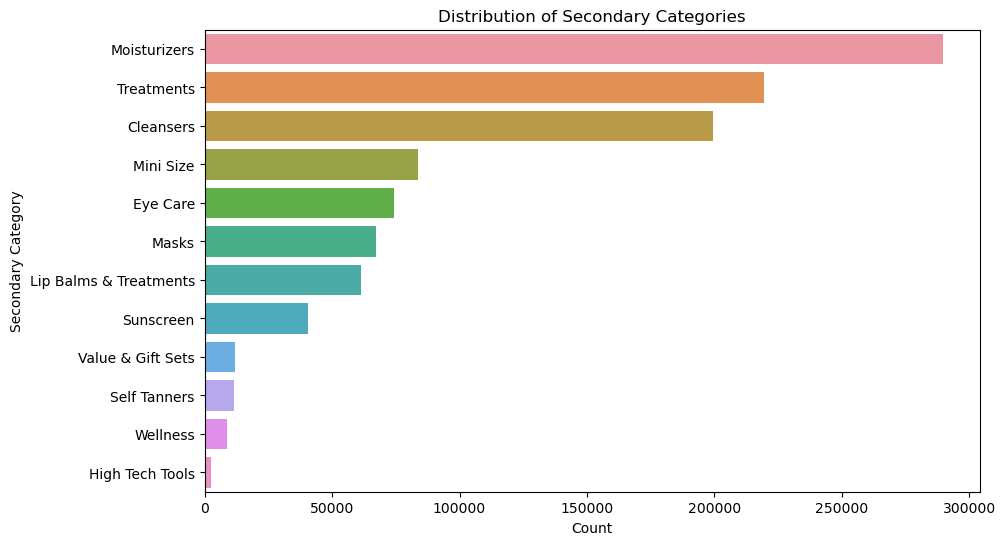

In [35]:
# Visualize the distribution of secondary_category
plt.figure(figsize=(10, 6))
sns.countplot(y='secondary_category', data=df, order=df['secondary_category'].value_counts().index)
plt.title("Distribution of Secondary Categories")
plt.xlabel("Count")
plt.ylabel("Secondary Category")
plt.show()


#### Categorical variables 

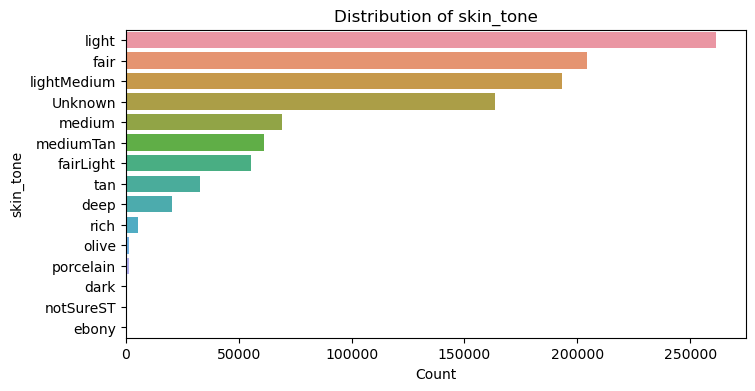

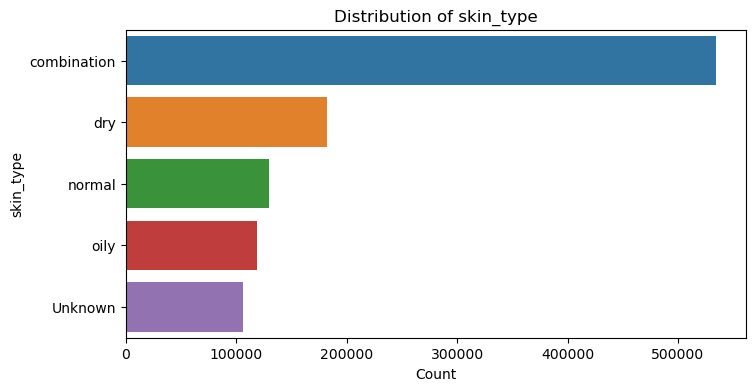

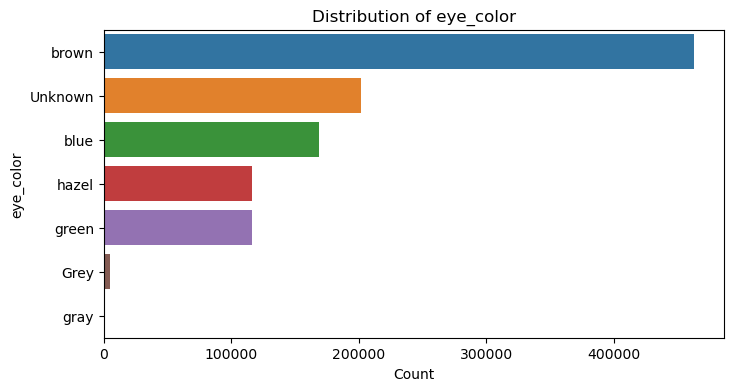

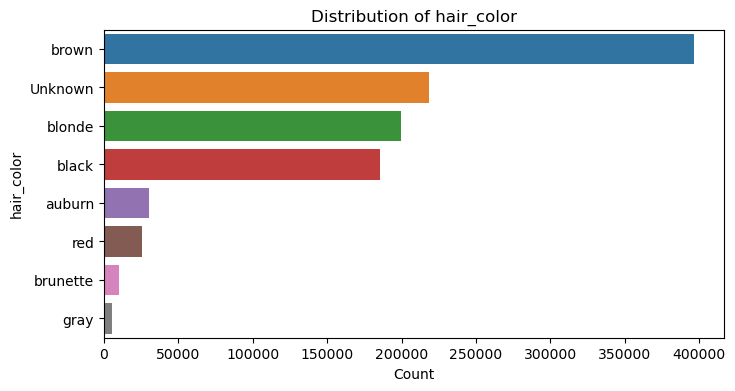

In [36]:
# Count plots for user-related categorical features
categorical_columns = ['skin_tone', 'skin_type', 'eye_color', 'hair_color']
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()


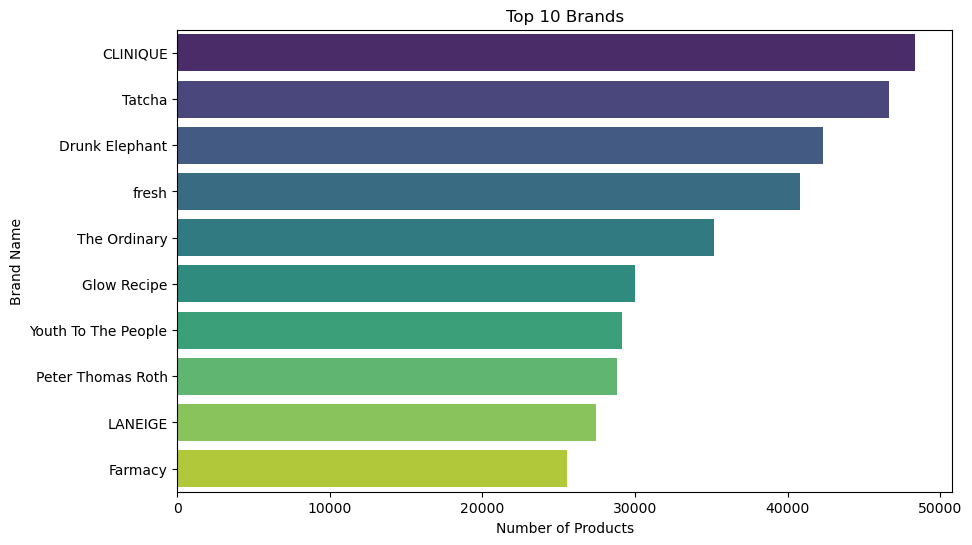

In [37]:
# Top 10 brands by count
top_brands = df['brand_name'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")
plt.title("Top 10 Brands")
plt.xlabel("Number of Products")
plt.ylabel("Brand Name")
plt.show()


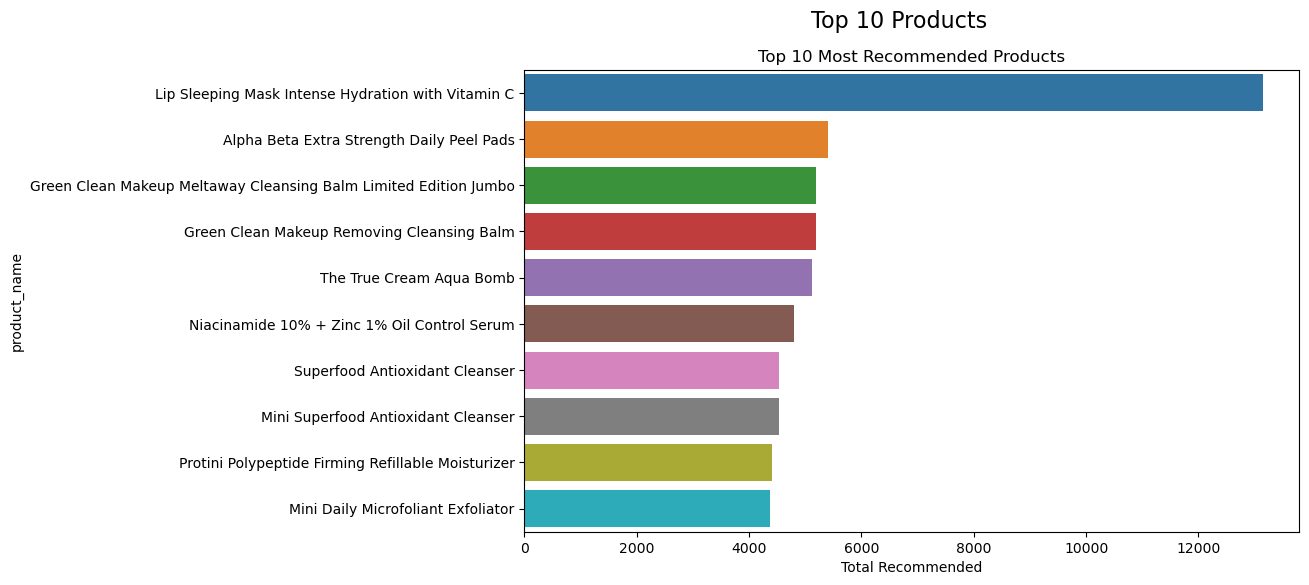

In [38]:
fig, ax1 = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(hspace=0.5)

# Top 10 Most Recommended Products:
# Group by product identifier fields and sum the 'is_recommended' column.
most_recommended = (df.groupby(['product_id', 'product_name', 'brand_name'])
                      .sum(numeric_only=True)['is_recommended']
                      .reset_index()
                      .sort_values('is_recommended', ascending=False)
                      .head(10))

# Create a bar plot for the top recommended products
sns.barplot(data=most_recommended, x='is_recommended', y='product_name', ax=ax1)
ax1.set_title("Top 10 Most Recommended Products")
ax1.set_xlabel("Total Recommended")

plt.suptitle("Top 10 Products", fontsize=16)
plt.show()

#### Numeric Columns

c:\Users\tanja\anaconda3\envs\sci-env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


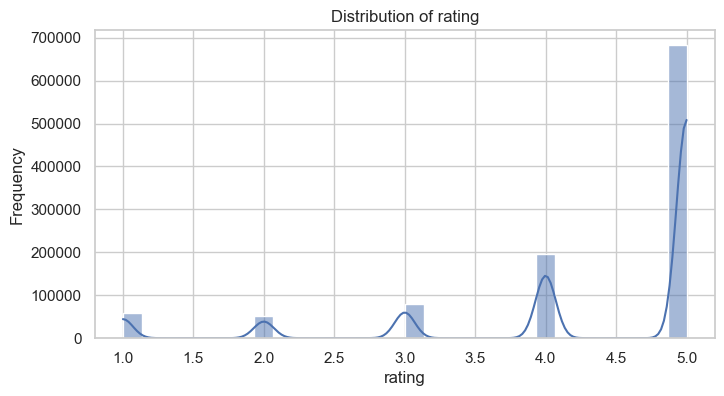

c:\Users\tanja\anaconda3\envs\sci-env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


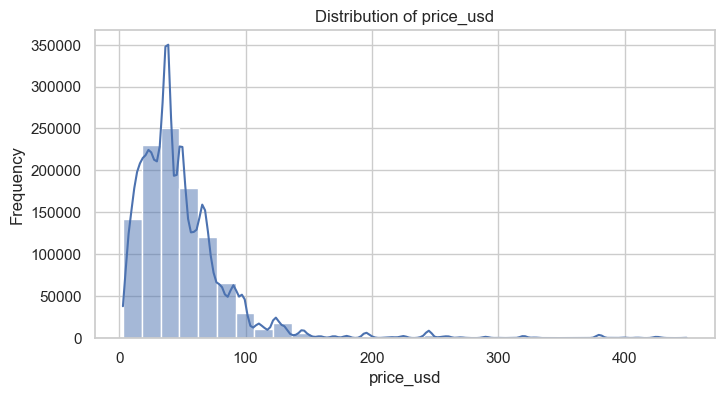

c:\Users\tanja\anaconda3\envs\sci-env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


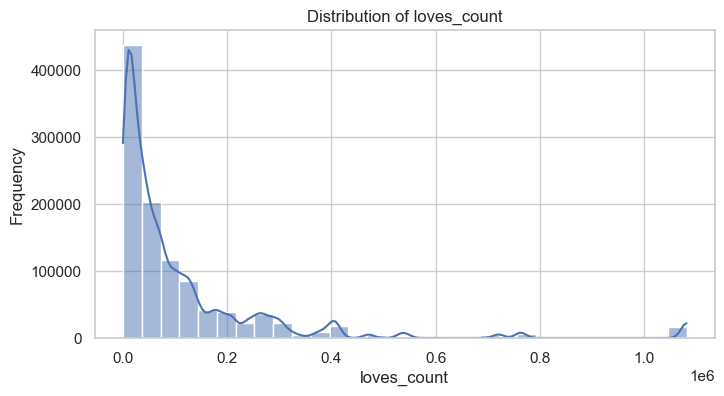

c:\Users\tanja\anaconda3\envs\sci-env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


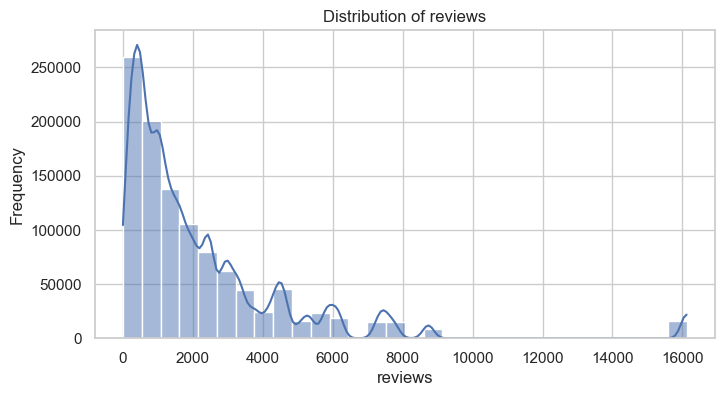

In [39]:
# Set style for better visuals
sns.set(style="whitegrid")

# Histograms for numeric columns
numeric_columns = ['rating', 'price_usd', 'loves_count', 'reviews']
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


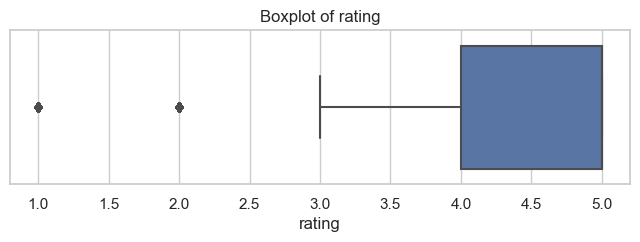

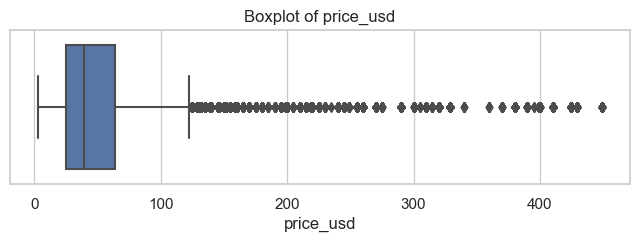

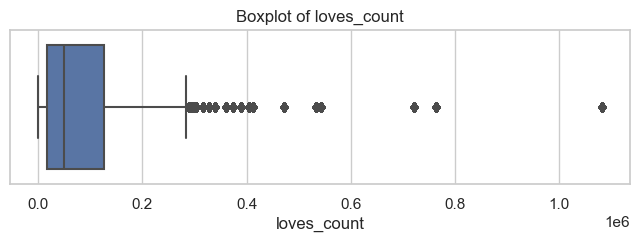

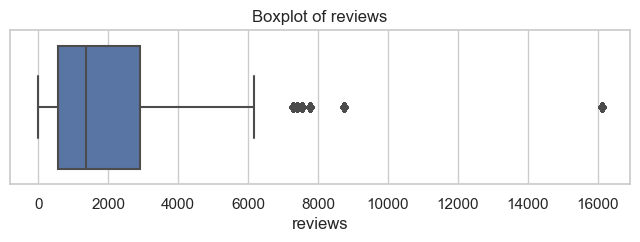

In [40]:
# List of numeric columns to analyze
numeric_columns = ['rating', 'price_usd', 'loves_count', 'reviews']

# Additionally, create boxplots to inspect potential outliers
for col in numeric_columns:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

#### Correlation and Relationship Analysis

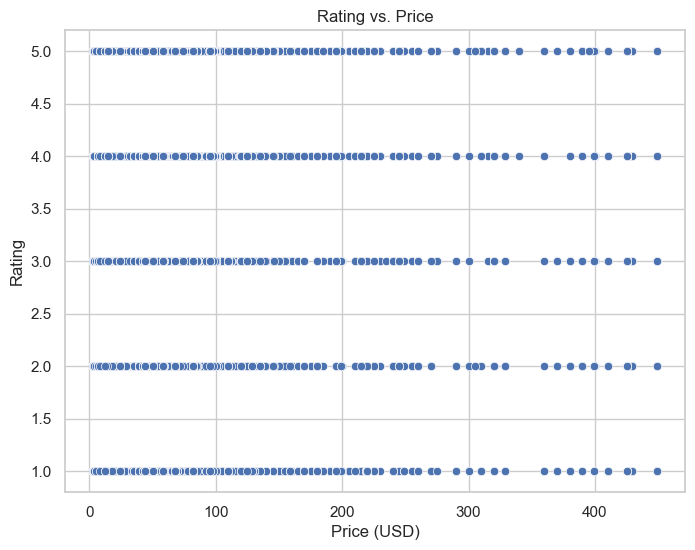

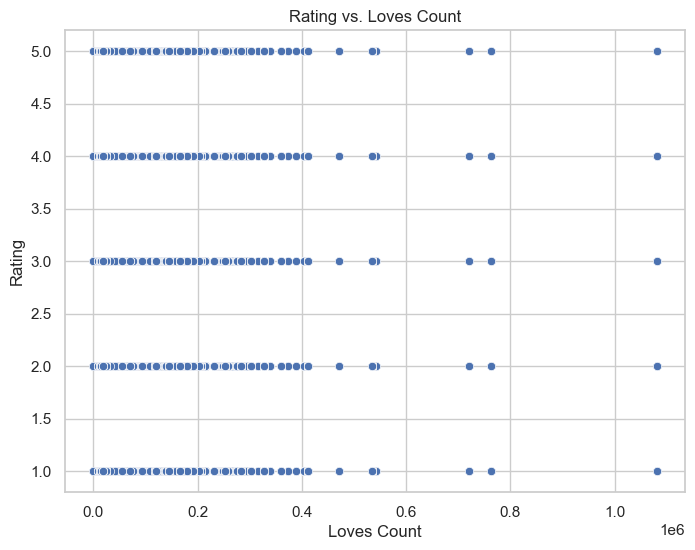

In [41]:
# Scatter plot for rating vs. price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='price_usd', y='rating', data=df)
plt.title("Rating vs. Price")
plt.xlabel("Price (USD)")
plt.ylabel("Rating")
plt.show()

# Scatter plot for rating vs. loves_count
plt.figure(figsize=(8, 6))
sns.scatterplot(x='loves_count', y='rating', data=df)
plt.title("Rating vs. Loves Count")
plt.xlabel("Loves Count")
plt.ylabel("Rating")
plt.show()


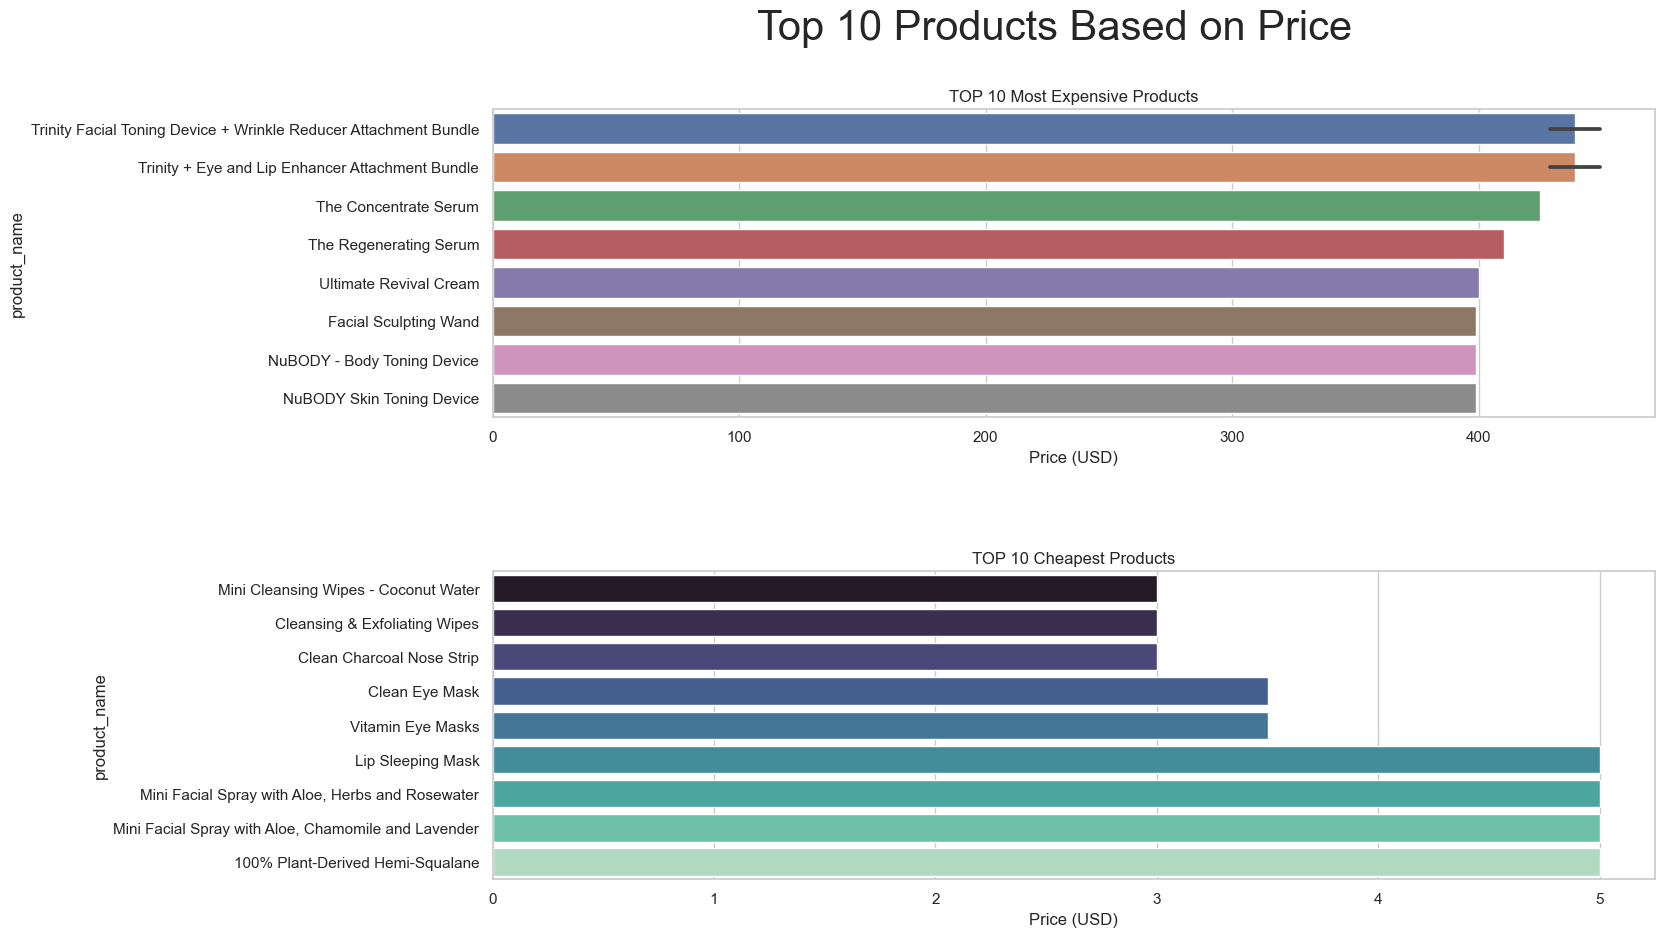

In [42]:
# Create a DataFrame with unique product information
product_prices = df[['product_id', 'product_name', 'price_usd']].drop_duplicates()

# Top 10 most expensive products (sorted descending by price)
most_expensive = product_prices.sort_values(by='price_usd', ascending=False).head(10)

# Top 10 cheapest products (sorted ascending by price)
cheapest = product_prices.sort_values(by='price_usd', ascending=True).head(10)

# Create subplots for the two bar plots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))
fig.subplots_adjust(hspace=0.5)

# Plot for Top 10 Most Expensive Products
sns.barplot(data=most_expensive, x='price_usd', y='product_name', ax=ax1)
ax1.set_title("TOP 10 Most Expensive Products")
ax1.set_xlabel("Price (USD)")

# Plot for Top 10 Cheapest Products
sns.barplot(data=cheapest, x='price_usd', y='product_name', ax=ax2, palette='mako')
ax2.set_title("TOP 10 Cheapest Products")
ax2.set_xlabel("Price (USD)")

plt.suptitle("Top 10 Products Based on Price", fontsize=30)
plt.show()

#### Text analysis

In [43]:
# Inspect sample reviews
print("Sample review_text:")
print(df['review_text'].dropna().head(10))

# Inspect sample ingredients
print("\nSample ingredients:")
print(df['ingredients'].dropna().head(10))


Sample review_text:
12    Nice consistency, however I’m not sure it’s do...
13    I cannot express how much I love this eye crea...
14    This depuffs super well. Does not help with da...
15    Love it! It keeps crows feet and fine lines aw...
16    I’m 46, and I can honestly say this has helped...
17    It was ok but no different frommy other cream ...
18    Cute packaging I’m really impressed with the r...
19    This is my favorited night time eye cream I ha...
20    I love this product. My fine lines around my e...
21    When applying onto under eyes make sure to not...
Name: review_text, dtype: object

Sample ingredients:
12    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
13    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
14    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
15    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
16    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
17    ['Water, Butylene Glycol, Tricaprylyl Citrate,...
18    ['Water, Butylene Glycol

#### Ingridents

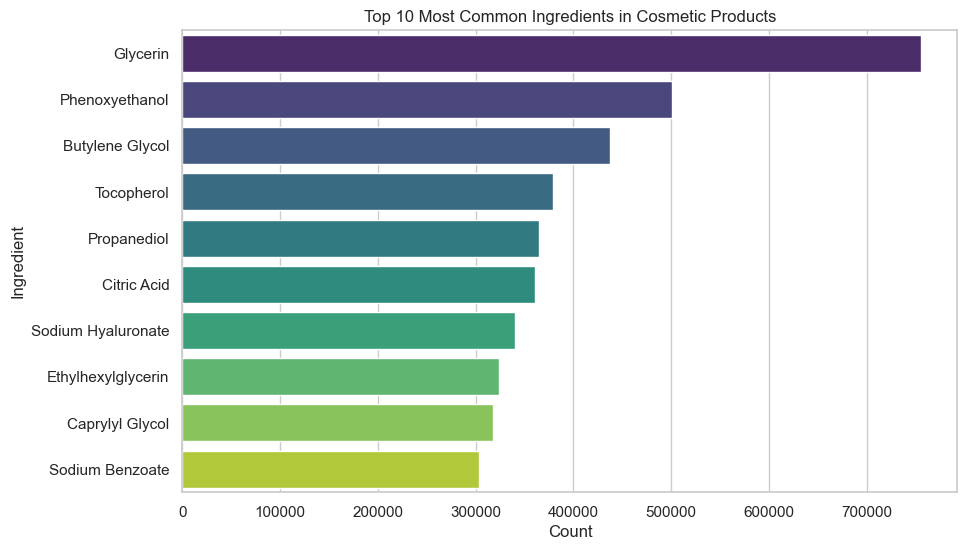

In [44]:
all_ingredients = [ingredient for ingredients in df['ingredients'] for ingredient in ingredients.split(', ')]
ingredient_counts = Counter(all_ingredients)

# Convert to a DataFrame for better visualization
ingredient_counts_df = pd.DataFrame(ingredient_counts.items(), columns=['Ingredient', 'Count']).sort_values(by='Count', ascending=False)

# Display the top 10 most common ingredients
top_10 = ingredient_counts_df.head(10)

# Plot the top 10 most common ingredients
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Ingredient', data=top_10, palette='viridis')
plt.title("Top 10 Most Common Ingredients in Cosmetic Products")
plt.xlabel("Count")
plt.ylabel("Ingredient")
plt.show()


#### Ingridents base

To allow customers to filter products based on whether they are water-based or silicone-based, we need to:

- Define key ingredients that indicate a water-based or silicone-based product.
- Create new boolean columns (water_based, silicone_based) in the dataset.

In [45]:
# Define key identifiers for water and silicone
water_keywords = ['water', 'aqua', 'hydrosol']
silicone_keywords = [
    'cyclopentasiloxane',
    'cyclohexasiloxane',
    'dimethicone',
    'trimethicone',
    'amodimethicone',
    'vinyl dimethicone',
    'cetyl dimethicone',
    'phenyl trimethicone',
    'silicone'
]

# Create flags indicating the presence of water-based or silicone-based ingredients
df['water_based'] = df['ingredients'].apply(
    lambda ingredients: any(keyword in ingredients.lower() for keyword in water_keywords)
)
df['silicone_based'] = df['ingredients'].apply(
    lambda ingredients: any(keyword in ingredients.lower() for keyword in silicone_keywords)
)

# Check the result
print(df[['product_name', 'water_based', 'silicone_based']].head(5))


          product_name  water_based  silicone_based
12  Renewing Eye Cream         True            True
13  Renewing Eye Cream         True            True
14  Renewing Eye Cream         True            True
15  Renewing Eye Cream         True            True
16  Renewing Eye Cream         True            True


In [46]:
# Count distinct products by water_based/silicone_based flags
counts = df.groupby(['water_based', 'silicone_based'])['product_id'].nunique()

print(counts)


water_based  silicone_based
False        False              204
             True                28
True         False             1308
             True               683
Name: product_id, dtype: int64


#### Reviews text

In [47]:
# Download required NLTK data files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Set up stop words and the lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_review(review):
    """
    Cleans a review string by lowercasing, tokenizing, removing punctuation,
    filtering out stop words, and lemmatizing tokens.
    
    Parameters:
    - review (str): The original review text.
    
    Returns:
    - List[str]: A list of cleaned tokens.
    """
    if isinstance(review, str):
        # Convert text to lowercase
        review = review.lower()
        # Tokenize text into words
        tokens = word_tokenize(review)
        # Remove punctuation and non-alphabetic tokens
        tokens = [word for word in tokens if word.isalpha()]
        # Remove stop words
        tokens = [word for word in tokens if word not in stop_words]
        # Lemmatize tokens
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        return tokens
    else:
        return []

# Example usage: Clean a sample review
sample_review = "This is hands down the best cleanser I’ve ever used!"
cleaned_tokens = clean_review(sample_review)
print(cleaned_tokens)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tanja\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tanja\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tanja\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['hand', 'best', 'cleanser', 'ever', 'used']


In [227]:
# Create a new column 'review_tokens' with the cleaned tokens
df['review_cleaned'] = df['review_text'].apply(clean_review)

# Display a few examples of the original review and its cleaned tokenized version
print(df[['review_text', 'review_cleaned']].head(10))

                                          review_text  \
12  Nice consistency, however I’m not sure it’s do...   
13  I cannot express how much I love this eye crea...   
14  This depuffs super well. Does not help with da...   
15  Love it! It keeps crows feet and fine lines aw...   
16  I’m 46, and I can honestly say this has helped...   
17  It was ok but no different frommy other cream ...   
18  Cute packaging I’m really impressed with the r...   
19  This is my favorited night time eye cream I ha...   
20  I love this product. My fine lines around my e...   
21  When applying onto under eyes make sure to not...   

                                       review_cleaned  
12  [nice, consistency, however, sure, promised, n...  
13  [express, much, love, eye, cream, driest, flak...  
14  [depuffs, super, well, help, dark, circle, tho...  
15  [love, keep, crow, foot, fine, line, away, wea...  
16  [honestly, say, helped, wrinkle, puffiness, ey...  
17  [ok, different, frommy, cream, s

Generating word clouds for positive and negative reviews to visualize the most frequent words can help you understand the overall sentiment and themes in the data.

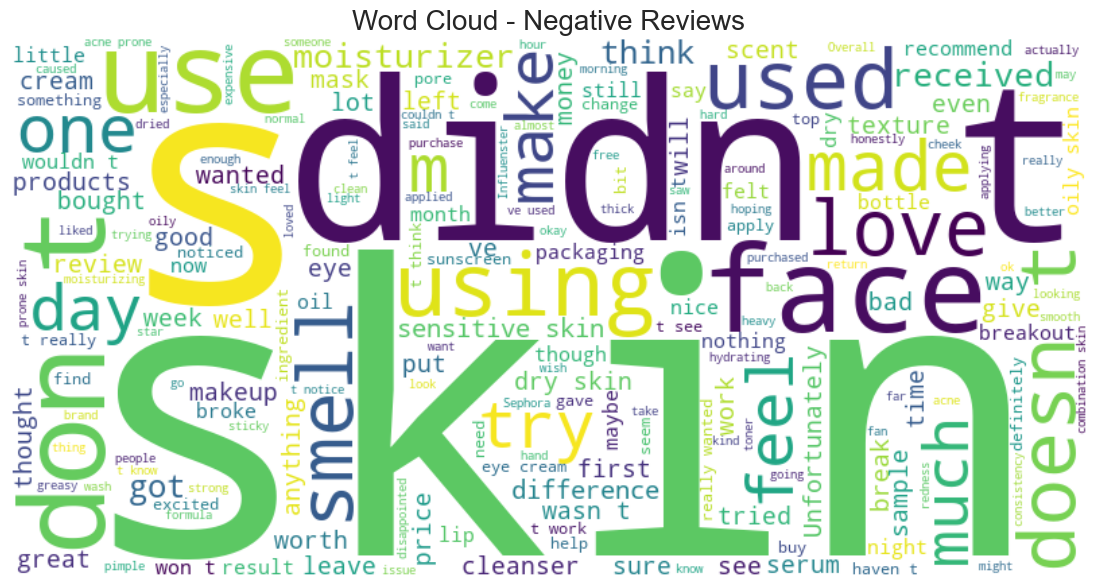

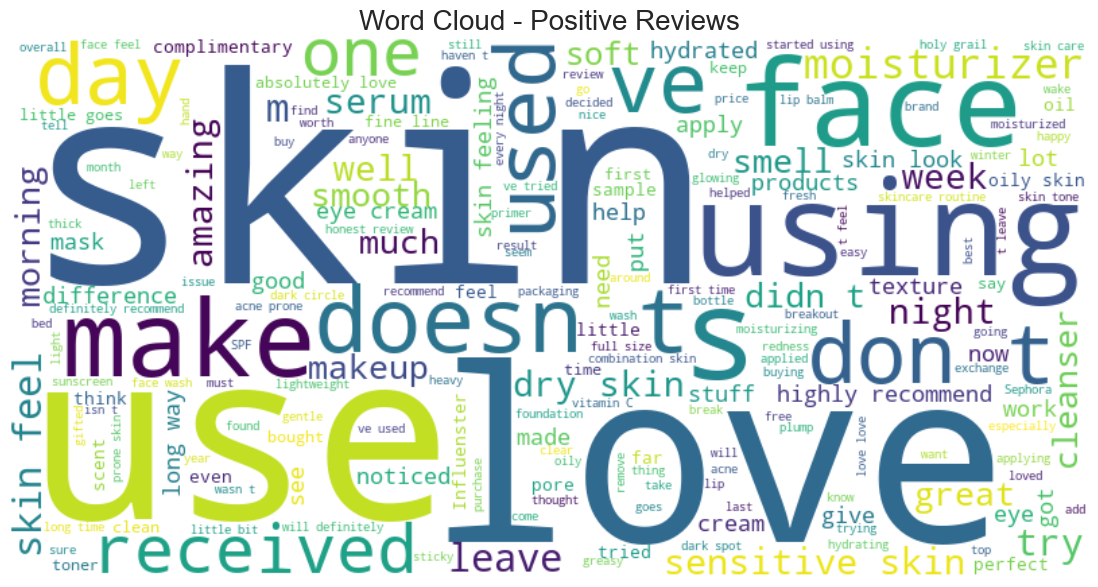

In [228]:

# Split the dataset into negative and positive reviews based on a rating threshold (e.g., 4)
negative_df = df[df['rating'] <= 3]
positive_df = df[df['rating'] > 4]

# Concatenate all reviews into single strings
negative = " ".join(review for review in negative_df['review_text'].dropna())
positive = " ".join(review for review in positive_df['review_text'].dropna())

# Create a set of stop words and add any custom ones
stopwords = set(STOPWORDS)
stopwords.update(['read', 'more', 'product'])

def generate_wordcloud(data, title="Word Cloud"):
    wordcloud = WordCloud(stopwords=stopwords, background_color="white", width=800, height=400).generate(data)
    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=20)
    plt.show()

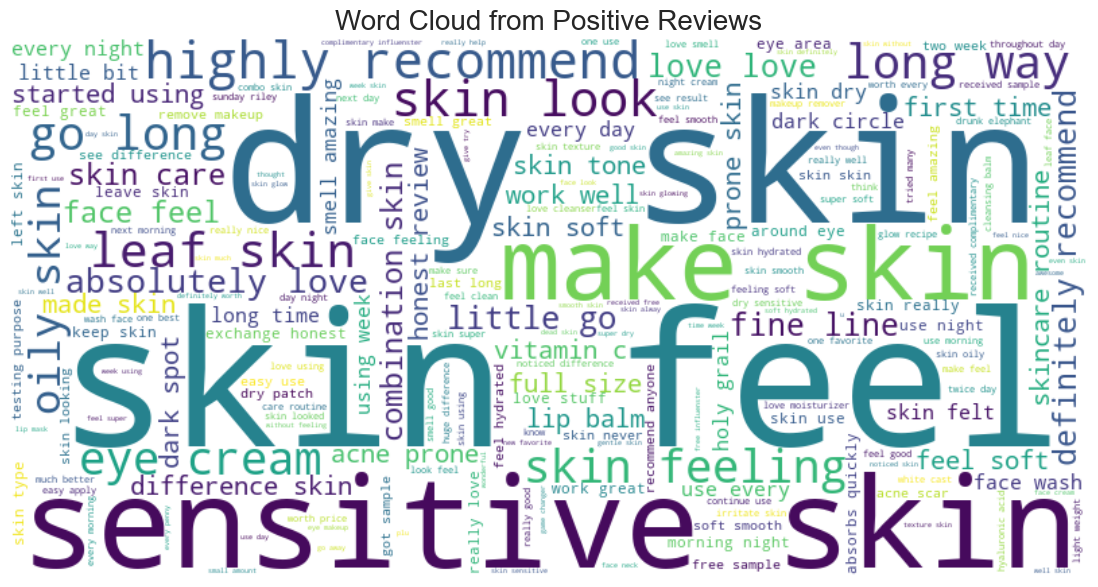

In [229]:
# Convert token lists back to a string for the word cloud (for positive reviews)
positive_tokens_string = " ".join([" ".join(tokens) for tokens in df[df['rating'] > 4]['review_cleaned'].dropna()])
generate_wordcloud(positive_tokens_string, title="Word Cloud from Positive Reviews")


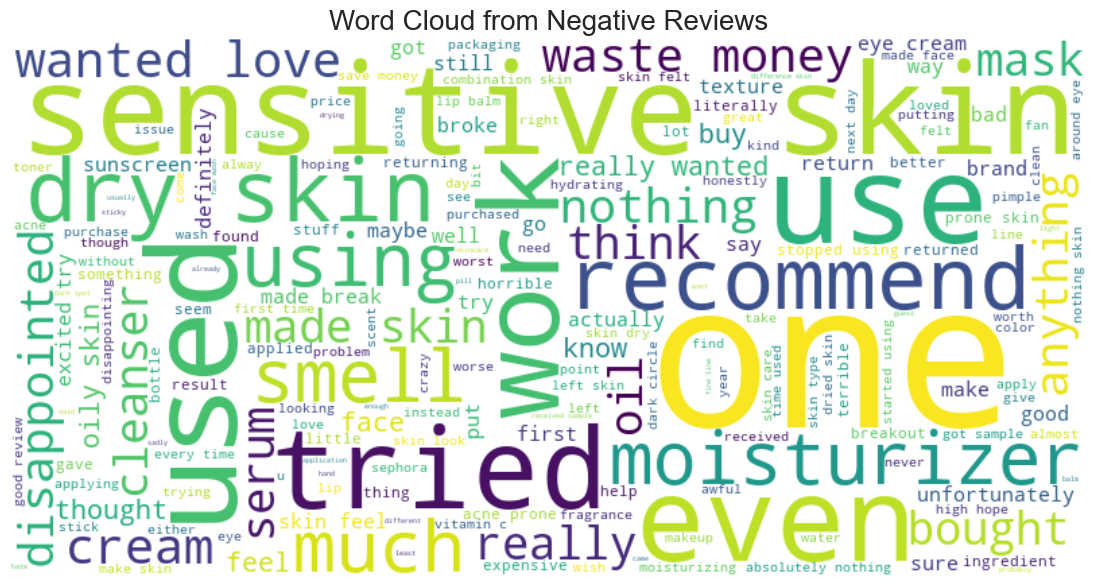

In [230]:
# Convert token lists back to a string for the word cloud (for negative reviews)
negative_tokens_string = " ".join([" ".join(tokens) for tokens in df[df['rating'] < 2]['review_cleaned'].dropna()])
generate_wordcloud(negative_tokens_string, title="Word Cloud from Negative Reviews")


Prepare the ingredients for the vectorization

In [48]:
def convert_list_to_string(val):
    """
    Convert a string representation of a list into a single string.
    
    Parameters:
        val (str): A string that represents a list, e.g., "['Water, Butylene Glycol, ...']".
        
    Returns:
        str: A single string with all the list items joined by a space.
    """
    try:
        # Safely evaluate the string to get an actual Python list
        items = ast.literal_eval(val)
        # If items is a list, join the elements; otherwise, return the original value.
        if isinstance(items, list):
            return " ".join(items)
        else:
            return val
    except Exception as e:
        # In case of any error (e.g., if it's not in list format), return the original value
        return val

# Apply this conversion to create a new column 'ingredients_cleaned'
df['ingredients_cleaned'] = df['ingredients'].apply(convert_list_to_string)

# Inspect the first few entries of the cleaned ingredients
print(df['ingredients_cleaned'].head(10))


12    Water, Butylene Glycol, Tricaprylyl Citrate, P...
13    Water, Butylene Glycol, Tricaprylyl Citrate, P...
14    Water, Butylene Glycol, Tricaprylyl Citrate, P...
15    Water, Butylene Glycol, Tricaprylyl Citrate, P...
16    Water, Butylene Glycol, Tricaprylyl Citrate, P...
17    Water, Butylene Glycol, Tricaprylyl Citrate, P...
18    Water, Butylene Glycol, Tricaprylyl Citrate, P...
19    Water, Butylene Glycol, Tricaprylyl Citrate, P...
20    Water, Butylene Glycol, Tricaprylyl Citrate, P...
21    Water, Butylene Glycol, Tricaprylyl Citrate, P...
Name: ingredients_cleaned, dtype: object


#### Save the dataset

In [49]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1070947 entries, 12 to 1100550
Data columns (total 20 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   author_id            1070947 non-null  object 
 1   rating               1070947 non-null  float64
 2   is_recommended       910353 non-null   float64
 3   review_text          1070947 non-null  object 
 4   skin_tone            1070947 non-null  object 
 5   eye_color            1070947 non-null  object 
 6   skin_type            1070947 non-null  object 
 7   hair_color           1070947 non-null  object 
 8   product_id           1070947 non-null  object 
 9   product_name         1070947 non-null  object 
 10  brand_name           1070947 non-null  object 
 11  price_usd            1070947 non-null  float64
 12  ingredients          1070947 non-null  object 
 13  loves_count          1070947 non-null  int64  
 14  out_of_stock         1070947 non-null  int64  
 15  re


**Dataset Changes Summary**

The original dataset underwent extensive cleaning and feature engineering, resulting in a final consolidated DataFrame with 1,070,962 entries and 18 columns. Key changes include:

- **Data Merging and Deduplication:**  
  Multiple data sources (such as user reviews and product information) were merged to create a comprehensive dataset, ensuring that each product-review record is uniquely identified by the common key `product_id`.

- **Removal of Unnecessary Columns:**  
  Columns that were deemed redundant or not useful for further analysis were dropped. This streamlined the dataset and reduced noise.

- **Handling Missing Values:**  
  Rows with missing values in critical text fields (e.g., ingredients and review_text) were removed to ensure reliable input for text analysis. Missing values in certain categorical fields (like skin_tone, eye_color, skin_type, and hair_color) were addressed by imputation or appropriate handling, resulting in complete records in key columns.

- **Text Cleaning and Tokenization:**  
  The raw review text was cleaned—converted to lowercase, stripped of punctuation, and extra spaces removed—to create a new column (`review_cleaned`). This prepared the text data for subsequent vectorization and analysis.

- **Consolidation of Key Information:**  
  The final dataset now includes essential columns such as `author_id`, `rating`, `is_recommended`, `review_text`, `review_cleaned`, as well as product details (`product_id`, `product_name`, `brand_name`, `price_usd`, and `ingredients`) along with user attributes (`skin_tone`, `eye_color`, `skin_type`, `hair_color`). Additional columns like `loves_count`, `new`, `out_of_stock`, and `reviews` provide further insights into product popularity and user engagement.

- **Ingredient Analysis Enhancements:**
  New feature engineering steps were added to flag water-based and silicone-based ingredients. Specifically, key identifiers were defined for water (including terms like "aqua" and "hydrosol") and silicone (with an expanded list including ingredients such as "cyclopentasiloxane", "cyclohexasiloxane", "dimethicone", and others). These flags (water_based and silicone_based) allow for quick identification of products based on their ingredient composition.


In [51]:
output_file = "cleaned_sephora_dataset.csv"
chunksize = 10000  # Adjust the chunk size as needed

with open(output_file, 'w', encoding='utf-8') as f:
    df.to_csv(f, index=False, chunksize=chunksize)

print(f"\nDataset successfully exported to {output_file}")



Dataset successfully exported to cleaned_sephora_dataset.csv
